In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob
from scipy.optimize import curve_fit
from scipy import special

In [2]:
sns.set_palette("rocket")

In [3]:
colors = sns.color_palette("rocket", n_colors=10)

In [4]:
devices = ['LMG365', 'LMG405', 'LMG450', 'LMG520', 'KAPU405', 'KAPU465']

In [5]:
pocam = '012'
hem = '17'

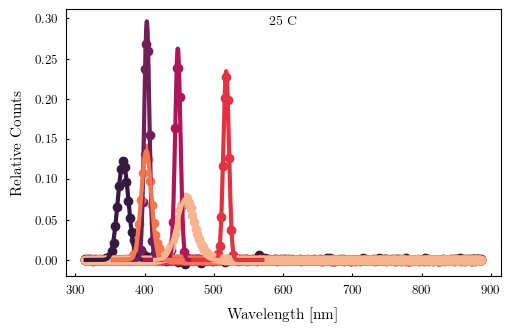

In [6]:
for device in devices:
    path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_25C.json'
    with open(path, 'r') as f:
        data = json.load(f)

    vals = data['meas_data'][0]
    wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
    plt.scatter(vals['x_values'], vals['y_values'])
    plt.plot(wl_fit, vals['fit_y_values'])
    plt.xlabel(vals['x_label'])
    plt.ylabel(vals['y_label'])
    T = vals['temperature']
    plt.title(f'{T} C')


In [7]:
Temperature=[-40,-30,-20, -10,0, 25 ]

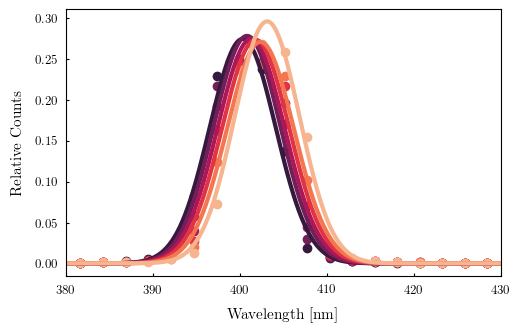

In [8]:
for T in Temperature:
    path = f'../output/batch2/pocam_{pocam}/hem_{hem}/LMG405/spec_{T}C.json'
    with open(path, 'r') as f:
        data = json.load(f)

    vals = data['meas_data'][0]
    wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
    plt.scatter(vals['x_values'], vals['y_values'])
    plt.plot(wl_fit, vals['fit_y_values'])
    plt.xlabel(vals['x_label'])
    plt.ylabel(vals['y_label'])
    plt.xlim(380,430)
#     Temp = vals['temperature']
#     plt.title(f'{Temp} C')


In [9]:
def gaussian(x, mean, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


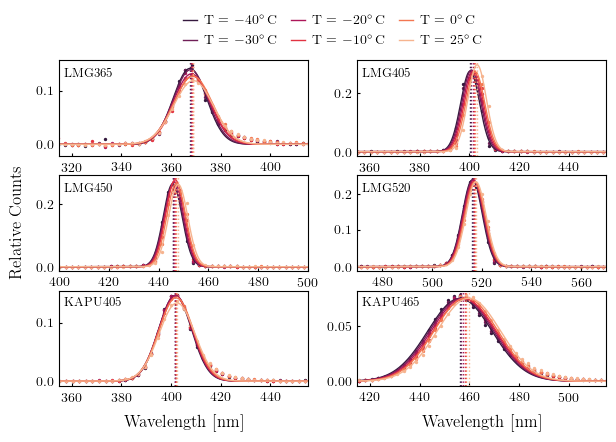

In [12]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    for j, T in enumerate(Temperature):
        photons_temp = []
        if "LMG" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'

        with open(path, 'r') as f:
            data = json.load(f)

        vals = data['meas_data'][0]
        fwhm = data['meas_data'][1]
        cwl = data['meas_data'][2]        
        wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
        ax.scatter(vals['x_values'], vals['y_values'], s = 2)
        fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                             p0 = [np.amax(vals['y_values']),  
                                   np.mean(vals['x_values']), 
                                   np.std(vals['x_values'])],
                             bounds=([0, np.amin(vals['x_values']), 0], 
                                     [np.inf, np.amax(vals['x_values']), np.inf]),
                             maxfev=10000)
        ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = f'T = ${T}^\circ\,$C')
        ax.axvline(fit[1], c = f'C{j}', lw =1, ls = ':')
        ax.set_xlim(vals['fit_x_min'], vals['fit_x_max'])
    if i == 2:
        ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                  bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if i in [4,5]:
        ax.set_xlabel(vals['x_label'])
    ax.text(0.02,0.83, f'{device}', transform = ax.transAxes, size = 9)
    
plt.savefig(f'plots/pdf/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_gauss_fit.pdf')
plt.savefig(f'plots/png/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_gauss_fit.png')

In [11]:
from scipy.interpolate import UnivariateSpline

In [18]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    wl = int(device[-3:])
    for j, T in enumerate(Temperature):
        photons_temp = []
        if "LMG" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'

        with open(path, 'r') as f:
            data = json.load(f)

        vals = data['meas_data'][0]
        fwhm = data['meas_data'][1]
        cwl = data['meas_data'][2]        
        
        x =  vals['x_values']
        y = vals['y_values']

        spline = UnivariateSpline(x, y, s=0.0001, k =5)

        spec_lspace = np.linspace(wl-50,wl+50, 1000)

        ax.scatter(x, y, s = 2)
        ax.plot(spec_lspace, spline(spec_lspace), lw=1, label = f'T = ${T}^\circ\,$C')

        idx = np.argmax(spline(spec_lspace))
        peak = spec_lspace[idx]
        ax.axvline(peak, c = f'C{j}', lw =1, ls = ':')

        ax.set_xlim(spec_lspace[0], spec_lspace[-1])

    if i == 2:
        ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                  bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if i in [4,5]:
        ax.set_xlabel(vals['x_label'])
    ax.text(0.02,0.83, f'{device}', transform = ax.transAxes, size = 9)
    
plt.savefig(f'plots/pdf/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_spline.pdf')
plt.savefig(f'plots/png/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_spline.png')

In [ ]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    for j, T in enumerate(Temperature):
        photons_temp = []
        if "LMG" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'

        with open(path, 'r') as f:
            data = json.load(f)

        vals = data['meas_data'][0]
        fwhm = data['meas_data'][1]
        cwl = data['meas_data'][2]        
        wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
        ax.scatter(vals['x_values'], vals['y_values'], s = 2)
        fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                             p0 = [np.amax(vals['y_values']),  
                                   np.mean(vals['x_values']), 
                                   np.std(vals['x_values'])],
                             bounds=([0, np.amin(vals['x_values']), 0], 
                                     [np.inf, np.amax(vals['x_values']), np.inf]),
                             maxfev=10000)
        ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = f'T = ${T}^\circ\,$C')
        ax.axvline(fit[1], c = f'C{j}', lw =1, ls = ':')
        ax.set_xlim(vals['fit_x_min'], vals['fit_x_max'])
    if i == 2:
        ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                  bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if i in [4,5]:
        ax.set_xlabel(vals['x_label'])
    ax.text(0.02,0.83, f'{device}', transform = ax.transAxes, size = 9)
    
plt.savefig('plots/pdf/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}.pdf')
plt.savefig('plots/png/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}.png')

In [12]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

wavelengths_dict_patrick={}
wavelengths_dict_elena={}

for device in devices:
    for j, T in enumerate(Temperature):
        wavelengths_dict_patrick[f'{device}_{T}'] = []
        wavelengths_dict_elena[f'{device}_{T}'] = []
        if "LMG" in device:
            filenames_1 = f'../output/batch2/pocam_*/hem_*/{device}/spec_{T:.0f}C_1_20.json'
            filenames_2 = f'../output/batch1/pocam_*/hem_*/{device}/spec_{T:.0f}C_2_20.json'
            filelist_1 = glob.glob(filenames_1)
            filelist_2 = glob.glob(filenames_2)
            filelist = np.concatenate((filelist_1, filelist_2))
        elif "KAPU" in device:
            filenames = f'../output/batch*/pocam_*/hem_*/{device}/spec_{T:.0f}C_default.json'
            filelist = glob.glob(filenames)
        
        print(device, T, len(filelist))
        for f in filelist:
            with open(f, 'r') as f:
                data = json.load(f)

            vals = data['meas_data'][0]
            fwhm = data['meas_data'][1]
            cwl = data['meas_data'][2]

            wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])

            fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                                 p0 = [np.amax(vals['y_values']),  
                                       np.mean(vals['x_values']), 
                                       np.std(vals['x_values'])],
                                 bounds=([0, np.amin(vals['x_values']), 0], 
                                         [np.inf, np.amax(vals['x_values']), np.inf]),
                                 maxfev=10000)
            wavelengths_dict_patrick[f'{device}_{T}'].append(cwl['value'])
            wavelengths_dict_elena[f'{device}_{T}'].append(fit[1])


LMG365 -40 50
LMG365 -30 50
LMG365 -20 50
LMG365 -10 50
LMG365 0 50
LMG365 25 50
LMG405 -40 50
LMG405 -30 50
LMG405 -20 50
LMG405 -10 50
LMG405 0 50
LMG405 25 50
LMG450 -40 50
LMG450 -30 50
LMG450 -20 50
LMG450 -10 50
LMG450 0 50
LMG450 25 50
LMG520 -40 50
LMG520 -30 50
LMG520 -20 50
LMG520 -10 50
LMG520 0 50
LMG520 25 50
KAPU405 -40 52
KAPU405 -30 52
KAPU405 -20 52
KAPU405 -10 52
KAPU405 0 52
KAPU405 25 52
KAPU465 -40 52
KAPU465 -30 52
KAPU465 -20 52
KAPU465 -10 52
KAPU465 0 52
KAPU465 25 52


Text(0.5, 1.1, 'LMG365')

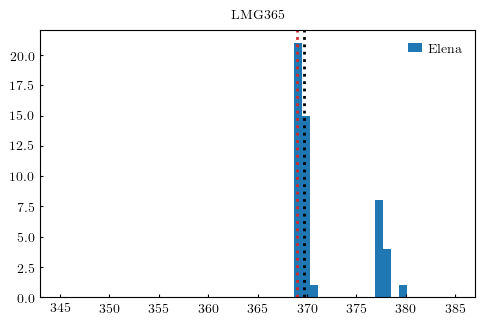

In [13]:
device = 'LMG365'
wl = int(device[-3:])
T =25

bins = np.linspace(wl-20,wl+20, 50)

plt.hist(wavelengths_dict_elena[f'{device}_{T}'], bins, color = 'tab:blue', label = 'Elena')
# plt.hist(wavelengths_dict_patrick[f'{device}_{T}'], bins, color = 'tab:orange', label = 'Patrick')
plt.axvline(np.median(wavelengths_dict_elena[f'{device}_{T}']), ls = ':', color = 'k')
plt.axvline(np.median(wavelengths_dict_patrick[f'{device}_{T}']), ls = ':', color = 'tab:red')
plt.legend()
plt.title(device, y = 1.1)

In [14]:
Temperature

[-40, -30, -20, -10, 0, 25]

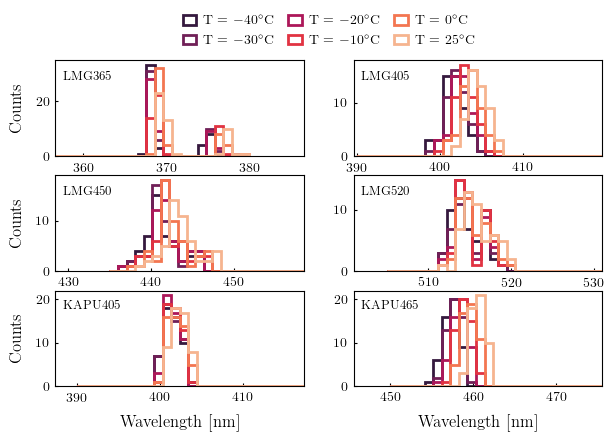

In [15]:
#make plot with 6 panels and plot one histo per each panel

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))


for i, ax in enumerate(axes.flat):
    device = devices[i]
    wl = int(device[-3:])

    tot_wl_elena = np.concatenate([wavelengths_dict_elena[f'{device}_{T}'] for T in Temperature])
    # tot_wl_patrick= np.concatenate([wavelengths_dict_patrick[f'{device}_{T}'] for T in Temperature])
    bins = np.linspace(wl-15,wl+15, 30)
    for T in Temperature:
        ax.hist(wavelengths_dict_elena[f'{device}_{T}'] , bins, histtype = 'step', lw =2, label = f'T = ${T}^\circ$C ')
        mean_wl = np.mean(wavelengths_dict_elena[f'{device}_{T}'])
        ax.set_xlim(mean_wl-15, mean_wl+15)
    ax.text(0.03,0.8, f'{device}', transform = ax.transAxes, size = 9)
    # ax.axvline(wl, ls = ':', color = 'k', lw = 1, label = 'Nominal Wavelength')
    # ax.axvline(wl, ls = ':', color = 'k', lw = 1, label = 'Nominal Wavelength')
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                  bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if np.isin(i, [4,5]):
        ax.set_xlabel('Wavelength [nm]')
    
    if np.isin(i, [0,2,4]):
        ax.set_ylabel('Counts')
    # ax.axvline(np.median(tot_wl_elena), ls = ':', color = 'k')

plt.savefig('plots/pdf/wavelength_hist_all_defalut_settings_allT_allPocams.pdf')
plt.savefig('plots/png/wavelength_hist_all_defalut_settings_allT_allPocams.png')

In [ ]:
Temperature=[-40,-30,-20]

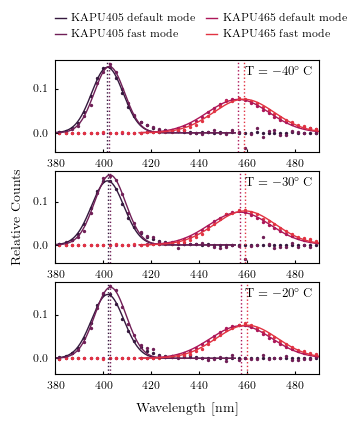

In [ ]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,1,figsize=plot_utils.set_size('colums', fraction=1,ratio = 0.4, subplots=(3, 1)))
for i, ax in enumerate(axes.flat):
    j = -1 
    T = Temperature[i]
    for kapu in ['KAPU405', 'KAPU465']:
        for mode in ['default','fast']:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{kapu}/spec_{T:.0f}C_{mode}.json'
            j = j+1
            with open(path, 'r') as f:
                data = json.load(f)
            
            label = f'{kapu} {mode} mode'
            
            vals = data['meas_data'][0]
            fwhm = data['meas_data'][1]
            cwl = data['meas_data'][2]        
            wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
            ax.scatter(vals['x_values'], vals['y_values'], s = 2)
            fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                                 p0 = [np.amax(vals['y_values']),  
                                       np.mean(vals['x_values']), 
                                       np.std(vals['x_values'])],
                                 bounds=([0, np.amin(vals['x_values']), 0], 
                                         [np.inf, np.amax(vals['x_values']), np.inf]),
                                 maxfev=10000)
            ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = label)
            ax.axvline(fit[1], c = f'C{j}', lw =1, ls = ':')
            ax.set_xlim(380, 490)
# if i == 2:
#     ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
              bbox_to_anchor = (.55,1.6), ncols = 2,columnspacing=1.0)
    if i ==2:
        ax.set_xlabel(vals['x_label'])
    if i ==1:
        ax.set_ylabel(vals['y_label'])
    
    ax.text(0.72,0.83, f'T = ${T}^\circ\,$C', transform = ax.transAxes, size = 9)
    
plt.savefig('plots/pdf/spectrum_kapu_defalut_fast_allT_pocam{pocam}_hem{hem}.pdf')
plt.savefig('plots/png/spectrum_kapu_defalut_fast_allT_pocam{pocam}_hem{hem}.png')

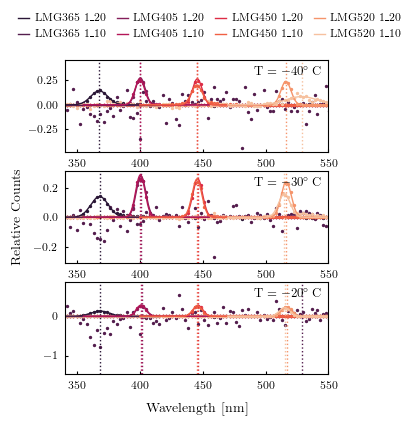

In [ ]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)
colors = sns.color_palette("rocket", n_colors=8)
fig, axes = plt.subplots(3,1,figsize=plot_utils.set_size('colums', fraction=1,ratio = 0.4, subplots=(3, 1)))
for i, ax in enumerate(axes.flat):
    j = -1 
    T = Temperature[i]
    for lmg in ['LMG365', 'LMG405', 'LMG450', 'LMG520']:
        for coarse_fine in ['1_20', '1_10']:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{lmg}/spec_{T:.0f}C_{coarse_fine}.json'
            j = j+1
            with open(path, 'r') as f:
                data = json.load(f)
            
            label = f'{lmg} {coarse_fine}'
            
            vals = data['meas_data'][0]
            fwhm = data['meas_data'][1]
            cwl = data['meas_data'][2]        
            wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
            ax.scatter(vals['x_values'], vals['y_values'], s = 2, color = colors[j])
            fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                                 p0 = [np.amax(vals['y_values']),  
                                       np.mean(vals['x_values']), 
                                       np.std(vals['x_values'])],
                                 bounds=([0, np.amin(vals['x_values']), 0], 
                                         [np.inf, np.amax(vals['x_values']), np.inf]),
                                 maxfev=10000)
            ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = label, color = colors[j])
            ax.axvline(fit[1], c = colors[j], lw =1, ls = ':')
            ax.set_xlim(340, 550)
# if i == 2:
#     ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
              bbox_to_anchor = (.55,1.6), ncols = 4,columnspacing=1.0)
    if i ==2:
        ax.set_xlabel(vals['x_label'])
    if i ==1:
        ax.set_ylabel(vals['y_label'])
    
    ax.text(0.72,0.83, f'T = ${T}^\circ\,$C', transform = ax.transAxes, size = 9)
    
plt.savefig('plots/pdf/spectrum_LMG_different_modes_allT_pocam{pocam}_hem{hem}.pdf')
plt.savefig('plots/png/spectrum_LMG_different_modes_allT_pocam{pocam}_hem{hem}.png')